In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import joblib
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report
import time

batch_size = 128
num_classes = 10
epochs = 12

history = {
    'train_loss': [],
    'test_loss': [],
    'test_accuracy': []
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

data_dir = '../../'
train_dataset = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3) # Only changed the netweork depth not width
        self.dropout1 = nn.Dropout2d(0.25)
        self.fc1 = nn.Linear(64 *5 * 5, 128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        # print("Shape after conv and pooling:", x.shape)  # Debugging line to check the shape
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        # print("Shape after flattening:", x.shape)  # Debugging line to check the shape
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

model = CNN().to(device)
optimizer = optim.Adadelta(model.parameters(), lr=1.0) # lr=1.0 is the default learning rate for Adadelta
criterion = nn.NLLLoss()

print(model)
print('Total parameters:', sum(p.numel() for p in model.parameters()))

Using device: cuda
CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Total parameters: 261962


In [3]:
def train(epoch):
    epoch_loss = 0
    model.train()
    start_time = time.time()
    for batch_idx, (data, target) in enumerate(train_loader, start=1):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}]'
                  f'  Loss: {loss.item():.4f}')
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader)
    end_time = time.time()
    return end_time - start_time, epoch_loss

def test():
    model.eval()
    test_loss = 0
    correct = 0

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            all_predictions.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    accuracy = 100.0 * correct / len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n')

    return {
        'loss': test_loss,
        'accuracy': accuracy,
        'targets': all_targets,
        'predictions': all_predictions
    }

for epoch in range(1, epochs + 1):
    training_time, train_loss = train(epoch)
    results = test()

    history['train_loss'].append(train_loss)
    history['test_loss'].append(results['loss'])
    history['test_accuracy'].append(results['accuracy'])
cm = confusion_matrix(results['targets'], results['predictions'])
report = classification_report(
    results['targets'],
    results['predictions'],
    output_dict=True
)


Train Epoch: 1 [12800/60000]  Loss: 0.3080
Train Epoch: 1 [25600/60000]  Loss: 0.1884
Train Epoch: 1 [38400/60000]  Loss: 0.1658
Train Epoch: 1 [51200/60000]  Loss: 0.0806

Test set: Average loss: 0.0394, Accuracy: 9863/10000 (98.63%)

Train Epoch: 2 [12800/60000]  Loss: 0.0290
Train Epoch: 2 [25600/60000]  Loss: 0.1279
Train Epoch: 2 [38400/60000]  Loss: 0.0334
Train Epoch: 2 [51200/60000]  Loss: 0.0335

Test set: Average loss: 0.0262, Accuracy: 9914/10000 (99.14%)

Train Epoch: 3 [12800/60000]  Loss: 0.0572
Train Epoch: 3 [25600/60000]  Loss: 0.0504
Train Epoch: 3 [38400/60000]  Loss: 0.0066
Train Epoch: 3 [51200/60000]  Loss: 0.0234

Test set: Average loss: 0.0282, Accuracy: 9902/10000 (99.02%)

Train Epoch: 4 [12800/60000]  Loss: 0.0063
Train Epoch: 4 [25600/60000]  Loss: 0.0633
Train Epoch: 4 [38400/60000]  Loss: 0.0355
Train Epoch: 4 [51200/60000]  Loss: 0.0267

Test set: Average loss: 0.0229, Accuracy: 9913/10000 (99.13%)

Train Epoch: 5 [12800/60000]  Loss: 0.1261
Train Epoch: 

In [4]:
parameter_count = sum(p.numel() for p in model.parameters())

experiment = {
    'name': 'Deeper CNN',
    'optimizer': optimizer.__class__.__name__,
    'batch_size': batch_size,
    'epochs': epochs,
    'parameter_count': parameter_count,
    'history': history,
    'accuracy': report['accuracy'],
    'precision': report['weighted avg']['precision'],
    'recall': report['weighted avg']['recall'],
    'f1': report['weighted avg']['f1-score'],
    'classification_report': report,
    'confusion_matrix': cm,
    'duration': training_time,  
    'architecture': str(model),
    'learning_rate': optimizer.param_groups[0]['lr'],  # Assuming a single parameter group
    'kernel_size': 3,
    'filters': '32, 64',  # List of filters for each convolutional layer
    'dropout_rates': '0.25, 0.5'  # List of dropout rates for each dropout layer
}

In [6]:
joblib.dump(experiment, '../dictionary/deeper_cnn_experiment.pkl')

torch.save(model.state_dict(), '../model/deeper_cnn_model.pt')

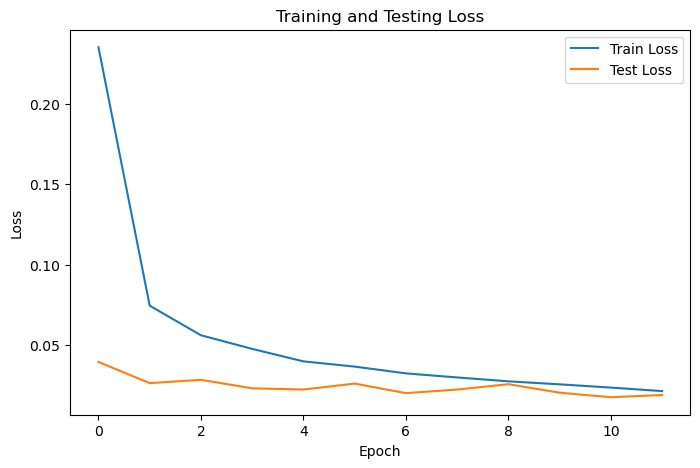

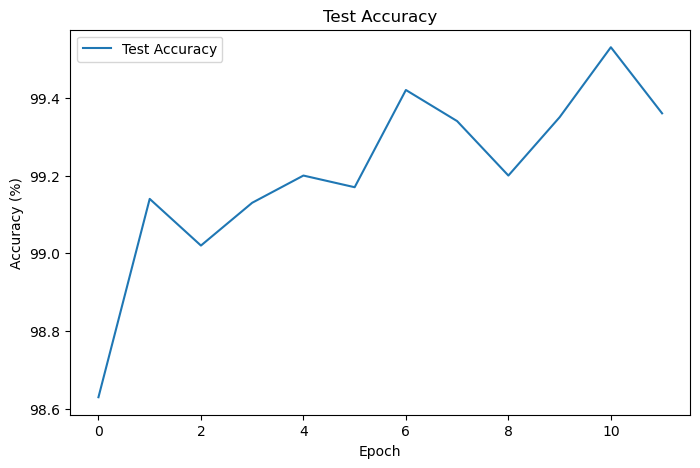

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history['test_accuracy'], label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy')
plt.legend()
plt.show()

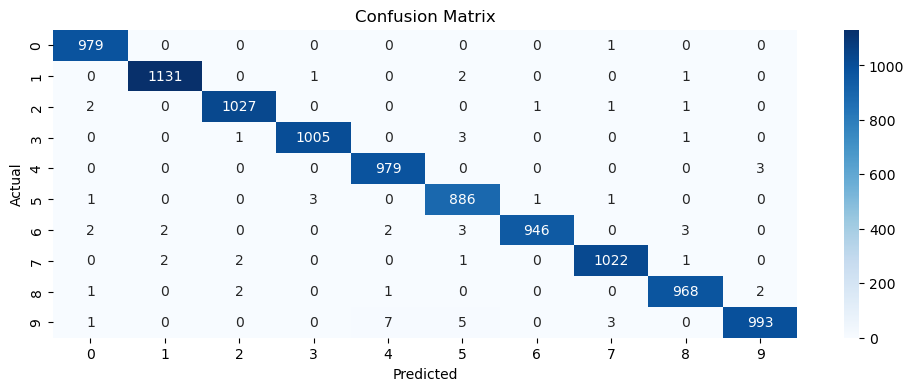

In [8]:
plt.figure(figsize=(12, 4))

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', cmap='Blues',
    xticklabels=range(num_classes), 
    yticklabels=range(num_classes)
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Confusion Matrix')
plt.show()